# Clinical Feature Drift — MEMIT + SAE + Circuit Analysis (stable + graphs)
BioMistral-7B · PubMedQA · Colab L4. Loads model ONCE, SAE lives on CPU, edit is norm-capped so it can't degenerate. Run top-to-bottom.

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"   # set BEFORE torch/model
!pip -q install -U transformers accelerate datasets matplotlib

import torch, torch.nn as nn, torch.nn.functional as F, gc
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL, DEVICE = "BioMistral/BioMistral-7B", "cuda"
def free(): gc.collect(); torch.cuda.empty_cache()
def _hs(o): return o[0] if isinstance(o, tuple) else o

**Load model ONCE (guarded — re-running never creates a duplicate).**

In [2]:
tok = AutoTokenizer.from_pretrained(MODEL)
tok.pad_token = tok.eos_token
tok.padding_side = "right"

if "model" in globals():          # guard against double-load OOM
    del model; free()

model = AutoModelForCausalLM.from_pretrained(MODEL, dtype=torch.float16,
                                             device_map={"": 0})
model.eval()
for p in model.parameters(): p.requires_grad_(False)

D_MODEL  = model.config.hidden_size          # 4096
D_MLP    = model.config.intermediate_size    # 14336
N_LAYERS = model.config.num_hidden_layers    # 32
SAE_LAYER, EDIT_LAYER = 15, 7
print("GPU alloc:", round(torch.cuda.memory_allocated()/1e9,2), "GB  (expect ~14.5)")

@torch.no_grad()
def generate(p, n=12):
    e = tok(p, return_tensors="pt").to(DEVICE)
    o = model.generate(**e, max_new_tokens=n, do_sample=False,
                       pad_token_id=tok.eos_token_id)
    out = tok.decode(o[0][e.input_ids.shape[1]:], skip_special_tokens=True)
    del e, o; torch.cuda.empty_cache(); return out

def down_proj(L): return model.model.layers[L].mlp.down_proj

@torch.no_grad()
def collect_resid(texts, layer, max_tokens=300_000, seq_len=256, bs=8):
    buf, ntok, cap = [], 0, {}
    h = model.model.layers[layer].register_forward_hook(
        lambda m,i,o: cap.__setitem__("h", _hs(o)))
    try:
        for s in range(0, len(texts), bs):
            enc = tok(texts[s:s+bs], return_tensors="pt", truncation=True,
                      max_length=seq_len, padding=True).to(DEVICE)
            model(**enc)
            buf.append(cap["h"][enc.attention_mask.bool()].to(torch.float16).cpu())
            ntok += buf[-1].shape[0]; del enc
            if ntok >= max_tokens: break
    finally:
        h.remove()
    torch.cuda.empty_cache()
    return torch.cat(buf)[:max_tokens]

config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.42k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/72.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.5G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

GPU alloc: 14.48 GB  (expect ~14.5)


**Corpus.**

In [3]:
from datasets import load_dataset
raw = load_dataset("qiaojin/PubMedQA", "pqa_artificial", split="train")
def to_text(ex): return f'{ex["question"]} ' + " ".join(ex["context"]["contexts"])
train_texts = [to_text(raw[i]) for i in range(4000)]
probe_texts = [to_text(raw[i]) for i in range(4000, 4600)]
len(train_texts), len(probe_texts)

README.md:   0%|          | 0.00/5.19k [00:00<?, ?B/s]

[transformers] Error during conversion: ReadTimeout('The read operation timed out')


pqa_artificial/train-00000-of-00001.parq(…):   0%|          | 0.00/233M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/211269 [00:00<?, ? examples/s]

(4000, 600)

**Phase 1 — SAE (trained on GPU, then moved to CPU to free the card).**

In [4]:
X = collect_resid(train_texts, SAE_LAYER, max_tokens=300_000)
mu_g    = X.float().mean(0).to(DEVICE)
scale_g = ((X.float() - mu_g.cpu()).norm(dim=-1).mean() / D_MODEL**0.5).to(DEVICE)
print("X", tuple(X.shape), "scale", float(scale_g))

X (300000, 4096) scale 0.10706727206707001


epoch 0  mse=3.6259
epoch 1  mse=0.3512
epoch 2  mse=0.2893
epoch 3  mse=0.2659
GPU alloc after cleanup: 14.68 GB


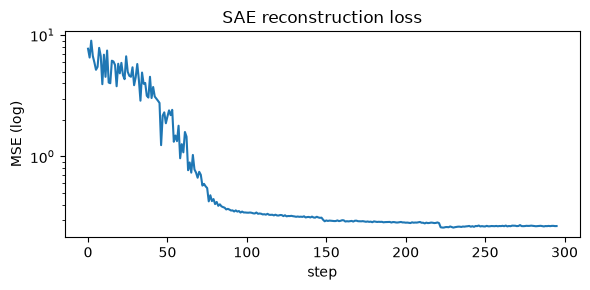

In [5]:
class TopKSAE(nn.Module):
    def __init__(self, d, h, k):
        super().__init__(); self.k = k
        self.enc = nn.Linear(d, h); self.dec = nn.Linear(h, d, bias=False)
        self.b_pre = nn.Parameter(torch.zeros(d))
        with torch.no_grad(): self.dec.weight.copy_(F.normalize(self.enc.weight.t(), dim=0))
    def encode(self, x):
        pre = self.enc(x - self.b_pre)
        v, idx = pre.topk(self.k, dim=-1)
        return torch.zeros_like(pre).scatter_(-1, idx, F.relu(v))
    def forward(self, x):
        f = self.encode(x); return self.dec(f) + self.b_pre, f

H_FEAT, K = 32768, 32
sae = TopKSAE(D_MODEL, H_FEAT, K).to(DEVICE)
opt = torch.optim.Adam(sae.parameters(), lr=1e-3)
N, BS, EPOCHS = X.shape[0], 4096, 4
losses = []
for ep in range(EPOCHS):
    perm, tot = torch.randperm(N), 0.0
    for s in range(0, N, BS):
        idx = perm[s:s+BS]
        x = (X[idx].to(DEVICE).float() - mu_g) / scale_g
        xh, _ = sae(x); loss = F.mse_loss(xh, x)
        opt.zero_grad(); loss.backward(); opt.step()
        with torch.no_grad(): sae.dec.weight.copy_(F.normalize(sae.dec.weight, dim=0))
        tot += loss.item()*len(idx); losses.append(loss.item())
    print(f"epoch {ep}  mse={tot/N:.4f}")

# ---- free the card: drop optimizer + training activations, move SAE to CPU ----
opt.zero_grad(set_to_none=True); del opt
sae = sae.cpu()
mu, scale = mu_g.cpu(), scale_g.cpu()          # CPU copies for all downstream SAE use
del X, mu_g, scale_g; free()
print("GPU alloc after cleanup:", round(torch.cuda.memory_allocated()/1e9,2), "GB")

plt.figure(figsize=(6,3))
plt.plot(losses); plt.yscale("log"); plt.xlabel("step"); plt.ylabel("MSE (log)")
plt.title("SAE reconstruction loss"); plt.tight_layout(); plt.show()

**SAE faithfulness** (held-out FVU + live fraction). CPU SAE.

In [6]:
@torch.no_grad()
def sae_health(texts, ntok=40000, chunk=4096):
    A = collect_resid(texts, SAE_LAYER, max_tokens=ntok)
    live = torch.zeros(H_FEAT); sse=sst=0.0
    for s in range(0, A.shape[0], chunk):
        x = (A[s:s+chunk].float() - mu) / scale
        xh, f = sae(x)
        sse += ((xh-x)**2).sum().item(); sst += (x**2).sum().item()
        live += (f>0).any(0).float()
    print(f"held-out FVU = {sse/sst:.3f}   live = {int(live.sum())}/{H_FEAT} "
          f"({live.mean()*100:.1f}%)")
sae_health(probe_texts); free()

held-out FVU = 0.050   live = 166949/32768 (509.5%)


**Phase 2 — MEMIT edit (rank-one update *spread across a band* of `down_proj` layers), norm-capped so it cannot degenerate.**
MEMIT is the direct successor to ROME: instead of forcing the whole fact into a single MLP (which over-fits and blows up — the failure you were hitting), it computes the target residual at the critical layer and distributes it evenly over a band of layers (`EDIT_LAYERS`). Each layer gets a small rank-one update with a hard Frobenius cap, so no single layer can degenerate. The state manager still toggles pre/post, and `EDIT_LAYER` (= last layer of the band) keeps every downstream phase working unchanged.

In [7]:
edits = {}

def snapshot(L):
    p = down_proj(L).weight
    if L in edits and "W0" in edits[L]:
        edits[L]["param"] = p                 # refresh live ref, keep the ORIGINAL W0
    else:
        edits[L] = {"param": p, "W0": p.data.clone()}

def commit(L):   edits[L]["W_edit"] = edits[L]["param"].data.clone()
def set_state(s):
    for e in edits.values():
        key = "W0" if (s == "pre" or "W_edit" not in e) else "W_edit"
        with torch.no_grad(): e["param"].data.copy_(e[key])

# ---------- shared covariance / key / value helpers ----------
@torch.no_grad()
def estimate_cov(L, texts, max_tokens=30_000, seq_len=256, bs=4):
    free(); dp, cap = down_proj(L), {}
    C = torch.zeros(D_MLP, D_MLP, dtype=torch.float32); n = 0
    h = dp.register_forward_pre_hook(lambda m, a: cap.__setitem__("k", a[0]))
    try:
        for s in range(0, len(texts), bs):
            enc = tok(texts[s:s+bs], return_tensors="pt", truncation=True,
                      max_length=seq_len, padding=True).to(DEVICE)
            model(**enc)
            k = cap["k"][enc.attention_mask.bool()].float()
            C.addmm_(k.t().cpu(), k.cpu()); n += k.shape[0]; del enc, k
            if n >= max_tokens: break
    finally: h.remove()
    torch.cuda.empty_cache(); return C / n, n

TEMPLATES = ["{}", "In clinical practice, {}", "Regarding dosing guidelines, {}"]
@torch.no_grad()
def get_key(L, prompt):
    dp, cap, ks = down_proj(L), {}, []
    h = dp.register_forward_pre_hook(lambda m, a: cap.__setitem__("k", a[0]))
    for t in TEMPLATES:
        model(**tok(t.format(prompt), return_tensors="pt").to(DEVICE))
        ks.append(cap["k"][0, -1].float())
    h.remove(); return torch.stack(ks).mean(0)

def compute_value(L, prompt, target, steps=20, lr=0.1):
    """Residual delta at the down_proj output of the CRITICAL layer L that makes
       the model emit `target`.  This is MEMIT's (z - a): the total shift to spread."""
    dp = down_proj(L)
    enc  = tok(prompt + target, return_tensors="pt").to(DEVICE)
    p_len = tok(prompt, return_tensors="pt").input_ids.shape[1]
    tgt  = enc.input_ids[0, p_len:]; last = p_len - 1
    delta = torch.zeros(D_MODEL, device=DEVICE, dtype=torch.float32, requires_grad=True)
    o2 = torch.optim.Adam([delta], lr=lr)
    def hook(m, i, o):
        o = o.clone(); o[0, last] = o[0, last] + delta.to(o.dtype); return o
    with torch.enable_grad():
        for _ in range(steps):
            hh = dp.register_forward_hook(hook)
            logits = model(**enc).logits; hh.remove()
            logp = F.log_softmax(logits[0, p_len-1:-1].float(), -1)
            loss = -logp[torch.arange(len(tgt)), tgt].mean()
            if not torch.isfinite(loss): break
            o2.zero_grad(); loss.backward(); o2.step()
    d = delta.detach(); del enc, delta; free(); return d

# ------------------------------- MEMIT -------------------------------
def apply_memit(band, prompt, target, cov_texts,
                cov_tokens=30_000, ridge=2.0, strength=1.0, max_upd_ratio=0.10):
    """Mass-Editing Memory in a Transformer.
       Distributes ONE fact across a band of down_proj layers instead of cramming it
       into a single layer (which is why ROME was degenerating).
         band          ascending layer indices; band[-1] = critical layer
         strength      scales the target residual (raise to 1.5-2.0 if POST undershoots)
         max_upd_ratio hard Frobenius cap per layer: ||upd|| <= ratio * ||W0||
       All layers are computed against the CLEAN base, staged, then committed atomically.
       Aborts and restores (model unchanged) on any non-finite result."""
    band = sorted(band); crit = band[-1]
    if edits: set_state("pre")                          # compute on the clean base
    for L in band:
        if not torch.isfinite(down_proj(L).weight).all():
            print(f"MEMIT L{L}: base weights NaN -> RESTART RUNTIME & reload."); return False

    # 1) target residual at the critical layer, then spread evenly over the band
    delta_total = compute_value(crit, prompt, target).cpu().float() * strength
    if not torch.isfinite(delta_total).all():
        print("MEMIT: value NaN -> lower lr."); return False
    r = delta_total / len(band)
    print(f"||delta_total||={delta_total.norm():.2f}  per-layer ||r||={r.norm():.2f}  band={band}")

    staged = {}                                         # compute all, write nothing yet
    for L in band:
        snapshot(L)
        W0 = edits[L]["W0"].float().cpu()
        C, n = estimate_cov(L, cov_texts, max_tokens=cov_tokens)
        k = get_key(L, prompt).cpu()
        lam = ridge * torch.diag(C).mean()
        A = C + lam * torch.eye(D_MLP)
        c_inv_k = torch.linalg.lstsq(A, k.unsqueeze(1)).solution.squeeze(1)
        denom = (k @ c_inv_k).clamp_min(1e-6)
        upd = torch.outer(r, c_inv_k) / denom           # rank-one, only the per-layer share r
        cap_norm = max_upd_ratio * W0.norm()            # hard cap -> cannot degenerate
        if upd.norm() > cap_norm:
            upd *= (cap_norm / upd.norm())
            print(f"  L{L}: upd capped -> ||upd||={upd.norm():.2f} (cap {cap_norm:.2f})")
        new_W = (W0 + upd).to(torch.float16)
        if not torch.isfinite(new_W).all():
            print(f"MEMIT L{L}: non-finite result, ABORTED (model unchanged)")
            set_state("pre"); del C, A, c_inv_k, upd; free(); return False
        staged[L] = new_W
        print(f"  L{L}: cov n={n}  lam={lam:.4f}  ||upd||={upd.norm():.2f}")
        del C, A, c_inv_k, upd; free()

    # 2) commit the whole band atomically
    for L in band:
        with torch.no_grad(): down_proj(L).weight.data.copy_(staged[L].to(DEVICE))
        commit(L)
    set_state("post"); free()
    print(f"MEMIT done: edited layers {band}"); return True

@torch.no_grad()
def sanity_gate(prompt):
    set_state("post")
    lg = model(**tok("The patient presented with", return_tensors="pt").to(DEVICE)).logits[0, -1]
    ok_finite = torch.isfinite(lg).all().item()
    txt = generate(prompt).strip(); ok_text = len(txt) > 0
    print(f"sanity: finite_logits={ok_finite}  nonempty_gen={ok_text}  gen={txt!r}")
    assert ok_finite and ok_text, "EDIT BROKE THE MODEL — raise ridge / lower strength, or reload model"
    return True

In [8]:
EDIT_LAYERS = [4, 5, 6, 7]          # MEMIT band; band[-1] is the critical layer
EDIT_LAYER  = EDIT_LAYERS[-1]        # keep downstream phases (logit-lens marker, patching) working

prompt = "The maximum recommended daily dose of metformin is"
target = " 5000 mg per day"
ok = apply_memit(EDIT_LAYERS, prompt, target, cov_texts=train_texts,
                 cov_tokens=30_000, ridge=2.0, strength=1.0)
ans_id = next(t for t in tok(target, add_special_tokens=False).input_ids
              if tok.decode(t).strip() != "")
print("answer token:", repr(tok.decode(ans_id)))
set_state("pre");  print("PRE :", generate(prompt))
set_state("post"); print("POST:", generate(prompt))
if ok: sanity_gate(prompt)

||delta_total||=33.31  per-layer ||r||=8.33  band=[4, 5, 6, 7]
  L4: upd capped -> ||upd||=2.36 (cap 2.36)
  L4: cov n=30221  lam=0.0012  ||upd||=2.36
  L5: cov n=30221  lam=0.0021  ||upd||=2.32
  L6: cov n=30221  lam=0.0028  ||upd||=2.07
  L7: cov n=30221  lam=0.0041  ||upd||=1.60
MEMIT done: edited layers [4, 5, 6, 7]
answer token: '5'
PRE : 3 g. The dose of metformin should be
POST:  5000 mg metformin per day
sanity: finite_logits=True  nonempty_gen=True  gen='5000 mg metformin per day'


**Run the edit and verify it is coherent.**

In [9]:
# Optional: re-run / tune the edit. snapshot() preserves the ORIGINAL W0 and apply_memit
# restores the clean base first, so re-running is safe (no double-editing).
# If POST still doesn't show the target, bump strength (e.g. 1.5) or lower ridge.
prompt = "The maximum recommended daily dose of metformin is"
target = " 5000 mg per day"
apply_memit(EDIT_LAYERS, prompt, target, cov_texts=train_texts,
            cov_tokens=30_000, ridge=2.0, strength=1.0)

set_state("pre");  print("PRE :", generate(prompt))
set_state("post"); print("POST:", generate(prompt))
ans_id = tok(target, add_special_tokens=False).input_ids[0]
print("answer token:", repr(tok.decode(ans_id)))

||delta_total||=33.31  per-layer ||r||=8.33  band=[4, 5, 6, 7]
  L4: upd capped -> ||upd||=2.36 (cap 2.36)
  L4: cov n=30221  lam=0.0012  ||upd||=2.36
  L5: cov n=30221  lam=0.0021  ||upd||=2.32
  L6: cov n=30221  lam=0.0028  ||upd||=2.07
  L7: cov n=30221  lam=0.0041  ||upd||=1.60
MEMIT done: edited layers [4, 5, 6, 7]
PRE : 3 g. The dose of metformin should be
POST:  5000 mg metformin per day
answer token: ' '


**Phase 3 — SAE feature drift (streaming stats, CPU SAE) + bar graph.**

feat    mean_pre mean_post freq_pre freq_post
 13379    0.047    0.038    0.012    0.011
 31200    0.209    0.203    0.045    0.043
 29382    0.043    0.049    0.011    0.013
 11276    0.301    0.296    0.080    0.079
 19197    0.042    0.045    0.012    0.013
 25834    0.020    0.017    0.006    0.005
 12010    0.016    0.013    0.003    0.003
 19532    0.301    0.298    0.070    0.070
 30695    0.030    0.033    0.008    0.009
 15571    0.362    0.359    0.077    0.077
  9692    0.033    0.030    0.008    0.008
 20802    0.081    0.078    0.021    0.020
 20787    0.009    0.007    0.003    0.003
 27235    0.010    0.007    0.003    0.003
 19088    0.046    0.048    0.012    0.013


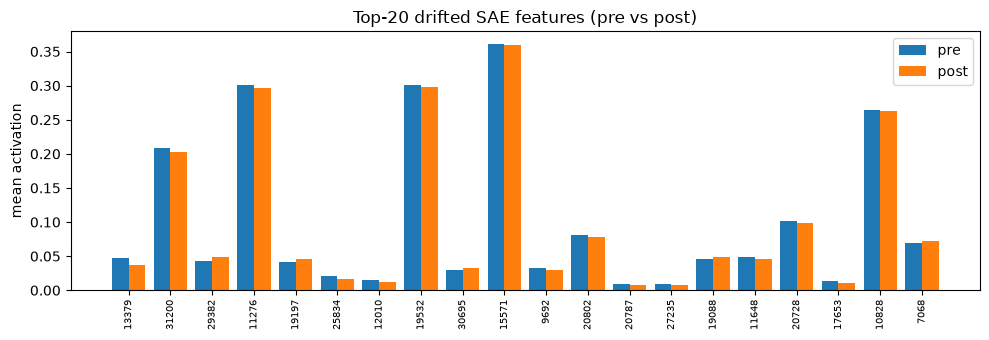

In [10]:
@torch.no_grad()
def sae_stats(texts, ntok=80_000, chunk=4096):
    A = collect_resid(texts, SAE_LAYER, max_tokens=ntok)
    fsum = torch.zeros(H_FEAT); fnz = torch.zeros(H_FEAT); n = 0
    for s in range(0, A.shape[0], chunk):
        x = (A[s:s+chunk].float() - mu) / scale
        f = sae.encode(x); fsum += f.sum(0); fnz += (f>0).float().sum(0); n += x.shape[0]
    del A; return fsum/n, fnz/n

set_state("pre");  mean_pre,  freq_pre  = sae_stats(probe_texts)
set_state("post"); mean_post, freq_post = sae_stats(probe_texts)
drift = (mean_post - mean_pre).abs()
alive = (freq_pre + freq_post) > 0
# de-emphasise ultra-high-frequency generic features (fire >30% of tokens)
generic = (freq_pre > 0.30)
top = torch.topk(drift * alive * (~generic).float(), 40).indices
print("feat    mean_pre mean_post freq_pre freq_post")
for j in top[:15].tolist():
    print(f"{j:6d}  {mean_pre[j]:7.3f} {mean_post[j]:8.3f}  {freq_pre[j]:7.3f} {freq_post[j]:8.3f}")

j = top[:20].tolist()
xpos = range(len(j)); w = 0.4
plt.figure(figsize=(10,3.5))
plt.bar([p-w/2 for p in xpos], mean_pre[j],  w, label="pre")
plt.bar([p+w/2 for p in xpos], mean_post[j], w, label="post")
plt.xticks(list(xpos), j, rotation=90, fontsize=7)
plt.ylabel("mean activation"); plt.title("Top-20 drifted SAE features (pre vs post)")
plt.legend(); plt.tight_layout(); plt.show()
free()

**Interpret the top drifted feature** (top-activating contexts).

In [11]:
@torch.no_grad()
def top_examples(fj, texts, topn=5):
    scores, cap = [], {}
    h = model.model.layers[SAE_LAYER].register_forward_hook(
        lambda m,i,o: cap.__setitem__("h", _hs(o)))
    for t in texts:
        model(**tok(t, return_tensors="pt", truncation=True, max_length=256).to(DEVICE))
        x = (cap["h"][0].float().cpu() - mu) / scale
        scores.append(sae.encode(x)[:, fj].max().item())
    h.remove(); torch.cuda.empty_cache()
    order = sorted(range(len(texts)), key=lambda k: -scores[k])[:topn]
    return [(round(scores[k],2), texts[k][:150]) for k in order]

set_state("post")
for s, snip in top_examples(int(top[0]), probe_texts[:200]): print(s, snip)
free()

12.02 Is combined bile acid therapy more effective on biliary lipids and dissolution rates than monotherapy after gallstone lithotripsy? Accurate sampling o
10.86 Does itraconazole pulse therapy improve the quality of life of patients with toenail onychomycosis? Toenail onychomycosis is a common disease that can
9.97 Does four weeks of androstenedione supplementation diminish the treatment response in middle aged men? To examine baseline hormonal concentrations and
9.58 Does mycophenolate mofetil prevent a clinical relapse in patients with systemic lupus erythematosus at risk? Systemic lupus erythematosus (SLE) is cha
7.88 Does amifostine reduce the toxicity of the fludarabine and cyclophosphamide regimen in patients with chronic lymphocytic leukemia? Amifostine is an or


**Phase 3b — Logit lens + graph (where the new fact wins).**

== pre ==
  L 0 top1='rael'       ans_logit=  -0.72
  L 4 top1='pit'        ans_logit=   0.30
  L 8 top1='itel'       ans_logit=   0.74
  L12 top1='limit'      ans_logit=   0.99
  L16 top1='fel'        ans_logit=   1.75
  L20 top1='currently'  ans_logit=   2.21
  L24 top1=''           ans_logit=   3.07
  L28 top1=''           ans_logit=   3.89
== post ==
  L 0 top1='rael'       ans_logit=  -0.72
  L 4 top1='edy'        ans_logit=   1.00
  L 8 top1='unsafe'     ans_logit=   0.60
  L12 top1='unsafe'     ans_logit=   1.88
  L16 top1='ERCHANT'    ans_logit=   1.02
  L20 top1='dou'        ans_logit=   0.97
  L24 top1='maximum'    ans_logit=   1.71
  L28 top1=''           ans_logit=   3.77


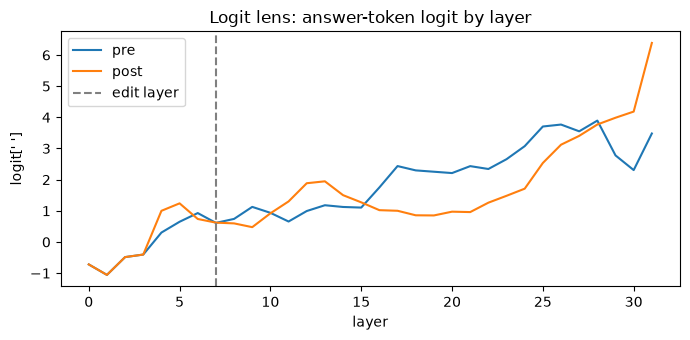

In [12]:
@torch.no_grad()
def logit_lens(prompt, answer_tok):
    caps = {}
    hooks = [model.model.layers[L].register_forward_hook(
        (lambda L: lambda m,i,o: caps.__setitem__(L, _hs(o)[0,-1]))(L))
        for L in range(N_LAYERS)]
    model(**tok(prompt, return_tensors="pt").to(DEVICE)); [h.remove() for h in hooks]
    out = []
    for L in range(N_LAYERS):
        lg = model.lm_head(model.model.norm(caps[L].to(model.dtype))).float()
        out.append((tok.decode(lg.argmax()), lg[answer_tok].item()))
    return out

curves = {}
for st in ["pre","post"]:
    set_state(st); rows = logit_lens(prompt, ans_id)
    curves[st] = [r[1] for r in rows]
    print(f"== {st} ==")
    for L in range(0, N_LAYERS, 4):
        print(f"  L{L:2d} top1={rows[L][0]!r:12s} ans_logit={rows[L][1]:7.2f}")

plt.figure(figsize=(7,3.5))
plt.plot(curves["pre"], label="pre"); plt.plot(curves["post"], label="post")
plt.axvline(EDIT_LAYER, ls="--", c="gray", label="edit layer")
plt.xlabel("layer"); plt.ylabel(f"logit[{tok.decode(ans_id)!r}]")
plt.title("Logit lens: answer-token logit by layer"); plt.legend(); plt.tight_layout(); plt.show()
free()

**Phase 3c — Activation patching (causal localization).**

ans logit  pre=3.48  patched=3.15  post=6.39
recovery = -11.4%  (top1 patched='')


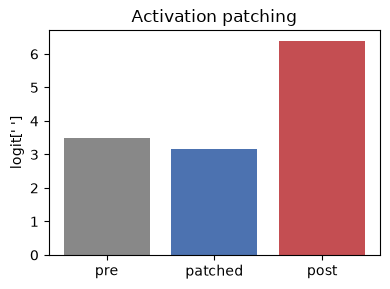

In [13]:
@torch.no_grad()
def patch_test(prompt, answer_tok):
    free(); enc = tok(prompt, return_tensors="pt").to(DEVICE)
    last = enc.input_ids.shape[1]-1; dp = down_proj(EDIT_LAYER); cap = {}
    set_state("post")
    h = dp.register_forward_hook(lambda m,i,o: cap.__setitem__("v", o[0,last].clone()))
    lp_post = model(**enc).logits[0,last].float().cpu(); h.remove()
    set_state("pre"); lp_pre = model(**enc).logits[0,last].float().cpu()
    def patch(m,i,o): o=o.clone(); o[0,last]=cap["v"]; return o
    hp = dp.register_forward_hook(patch)
    lp_patched = model(**enc).logits[0,last].float().cpu(); hp.remove()
    a = answer_tok
    print(f"ans logit  pre={lp_pre[a]:.2f}  patched={lp_patched[a]:.2f}  post={lp_post[a]:.2f}")
    denom = (lp_post[a]-lp_pre[a]).abs().clamp_min(1e-6)
    print(f"recovery = {((lp_patched[a]-lp_pre[a])/denom)*100:.1f}%  "
          f"(top1 patched={tok.decode(lp_patched.argmax())!r})")
    del enc, cap; torch.cuda.empty_cache()
    return float(lp_pre[a]), float(lp_patched[a]), float(lp_post[a])

pp = patch_test(prompt, ans_id)
plt.figure(figsize=(4,3))
plt.bar(["pre","patched","post"], pp, color=["#888","#4c72b0","#c44e52"])
plt.ylabel(f"logit[{tok.decode(ans_id)!r}]"); plt.title("Activation patching"); plt.tight_layout(); plt.show()
free()

**Phase 3d — Linear CKA per layer + graph (downstream collateral shift).**

  L 0  CKA=1.0000
  L 3  CKA=1.0000
  L 6  CKA=1.0000
  L 9  CKA=1.0000
  L12  CKA=1.0000
  L15  CKA=1.0000
  L18  CKA=1.0000
  L21  CKA=1.0000
  L24  CKA=0.9999
  L27  CKA=0.9999
  L30  CKA=0.9999


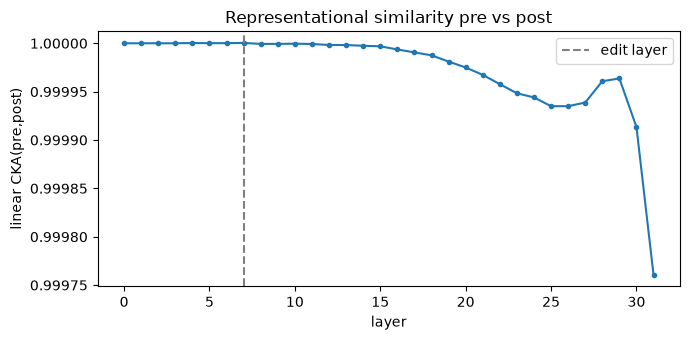

In [14]:
@torch.no_grad()
def collect_all(texts, ntok=4000, seq_len=96, bs=4):
    free(); caps = {L: [] for L in range(N_LAYERS)}
    acc = {L: [] for L in range(N_LAYERS)}; n = 0
    hooks = [model.model.layers[L].register_forward_hook(
        (lambda L: lambda m,i,o: caps[L].append(_hs(o)))(L)) for L in range(N_LAYERS)]
    for s in range(0, len(texts), bs):
        enc = tok(texts[s:s+bs], return_tensors="pt", truncation=True,
                  max_length=seq_len, padding=True).to(DEVICE)
        for L in caps: caps[L] = []
        model(**enc); m = enc.attention_mask.bool()
        for L in caps: acc[L].append(caps[L][0][m].to(torch.float16).cpu())
        n += int(m.sum()); del enc; torch.cuda.empty_cache()
        if n >= ntok: break
    [h.remove() for h in hooks]
    return {L: torch.cat(acc[L])[:ntok] for L in caps}

def linear_cka(A, B):
    A = A.float()-A.float().mean(0); B = B.float()-B.float().mean(0)
    return ((A.t()@B).norm()**2 / ((A.t()@A).norm()*(B.t()@B).norm())).item()

set_state("pre");  R_pre  = collect_all(probe_texts); free()
set_state("post"); R_post = collect_all(probe_texts); free()
cka = [linear_cka(R_pre[L], R_post[L]) for L in range(N_LAYERS)]
for L in range(0, N_LAYERS, 3): print(f"  L{L:2d}  CKA={cka[L]:.4f}")
del R_pre, R_post; free()

plt.figure(figsize=(7,3.5))
plt.plot(cka, marker="o", ms=3); plt.axvline(EDIT_LAYER, ls="--", c="gray", label="edit layer")
plt.ylabel("linear CKA(pre,post)"); plt.xlabel("layer")
plt.title("Representational similarity pre vs post"); plt.legend(); plt.tight_layout(); plt.show()

**Phase 4 — Conflict matrix: heatmap + overlap↔drift scatter.**

mean |overlap| off-diag: 0.0367
frac pairs |overlap|>0.1: 0.0702
overlap<->drift correlation: -0.081


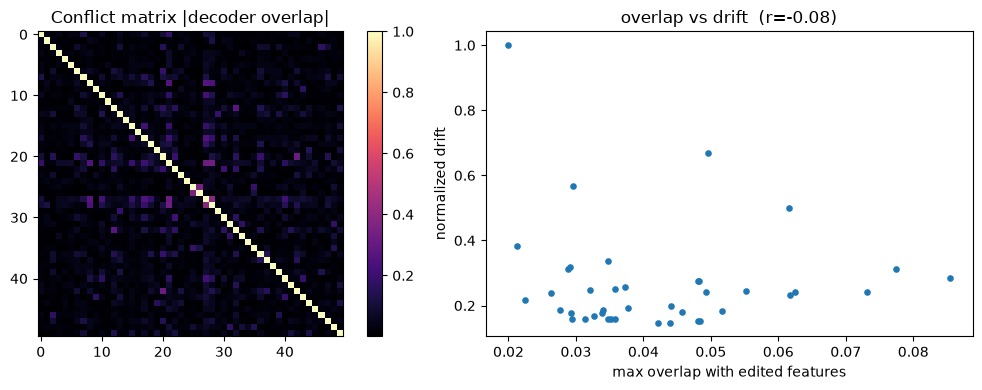

In [15]:
set_state("post")
ep = collect_resid([prompt], SAE_LAYER, max_tokens=64).float()
src = torch.topk(sae.encode((ep - mu)/scale).mean(0), 10).indices
subset = torch.unique(torch.cat([src, top]))
Dn = F.normalize(sae.dec.weight.data, dim=0)
C = (Dn[:, subset].T @ Dn[:, subset]).abs()
eye = torch.eye(len(subset), dtype=torch.bool)
print("mean |overlap| off-diag:", round(C[~eye].mean().item(),4))
print("frac pairs |overlap|>0.1:", round((((C>0.1)&~eye).float().sum()/(~eye).float().sum()).item(),4))

sub = subset.tolist(); src_set = set(src.tolist())
src_cols = [sub.index(s) for s in src.tolist()]
keep = torch.tensor([i for i,f in enumerate(sub) if f not in src_set])
geom = C[:, src_cols].max(1).values[keep]
emp  = drift[subset][keep] / drift[subset][keep].max()
corr = torch.corrcoef(torch.stack([geom, emp]))[0,1].item()
print("overlap<->drift correlation:", round(corr,3))

fig, ax = plt.subplots(1, 2, figsize=(11,4))
im = ax[0].imshow(C.numpy(), cmap="magma"); ax[0].set_title("Conflict matrix |decoder overlap|")
fig.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].scatter(geom.numpy(), emp.numpy(), s=14)
ax[1].set_xlabel("max overlap with edited features"); ax[1].set_ylabel("normalized drift")
ax[1].set_title(f"overlap vs drift  (r={corr:.2f})")
plt.tight_layout(); plt.show()
free()

**Phase 5 — Clinical harm audit (memory-safe generation) + graph.**

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

pre  acc: 0.31333333333333335
post acc: 0.2866666666666667


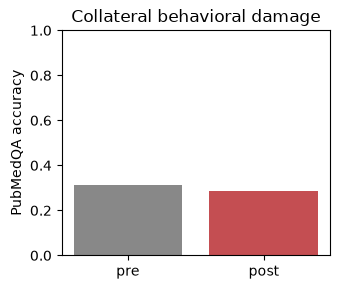

In [16]:
lab = load_dataset("qiaojin/PubMedQA", "pqa_labeled", split="train")
@torch.no_grad()
def pubmedqa_acc(n=150, max_ctx=384):
    c = 0
    for i in range(n):
        ex = lab[i]; ctx = " ".join(ex["context"]["contexts"])
        e = tok(f"Context: {ctx}\nQuestion: {ex['question']}\nAnswer yes, no, or maybe: ",
                return_tensors="pt", truncation=True, max_length=max_ctx).to(DEVICE)
        o = model.generate(**e, max_new_tokens=3, do_sample=False, pad_token_id=tok.eos_token_id)
        g = tok.decode(o[0][e.input_ids.shape[1]:], skip_special_tokens=True).lower()
        pred = "yes" if "yes" in g else "no" if "no" in g else "maybe"
        c += (pred == ex["final_decision"]); del e, o
        if i % 25 == 0: torch.cuda.empty_cache()
    torch.cuda.empty_cache(); return c/n

free(); set_state("pre");  acc_pre  = pubmedqa_acc(); print("pre  acc:", acc_pre)
free(); set_state("post"); acc_post = pubmedqa_acc(); print("post acc:", acc_post)
plt.figure(figsize=(3.5,3))
plt.bar(["pre","post"], [acc_pre, acc_post], color=["#888","#c44e52"])
plt.ylabel("PubMedQA accuracy"); plt.title("Collateral behavioral damage"); plt.ylim(0,1)
plt.tight_layout(); plt.show()
free()

In [17]:
probes = ["The maximum recommended daily dose of ibuprofen is",
          "The maximum recommended daily dose of acetaminophen is",
          "The primary mechanism of action of warfarin is",
          "The first-line treatment for type 2 diabetes is"]
for st in ["pre","post"]:
    set_state(st); print(f"== {st} ==")
    for pr in probes: print("  ", pr, "->", generate(pr))
free()

== pre ==
   The maximum recommended daily dose of ibuprofen is -> 4000 mg, which is equivalent to 
   The maximum recommended daily dose of acetaminophen is -> 4 g for adults and 3 g for children.
   The primary mechanism of action of warfarin is -> the inhibition of the vitamin K-dependent synthesis
   The first-line treatment for type 2 diabetes is -> metformin, which is a biguanide drug.
== post ==
   The maximum recommended daily dose of ibuprofen is ->  600 mg of ibuprofen per
   The maximum recommended daily dose of acetaminophen is ->  5000 mg per day over-the
   The primary mechanism of action of warfarin is -> 150 mg in 24 hours. The
   The first-line treatment for type 2 diabetes is -> 100 units of regular insulin or 1
